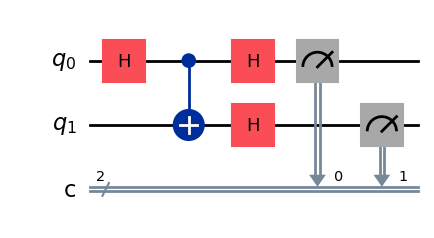

Computational (Z) basis counts: {'11': 507, '00': 517}
Hadamard (X) basis counts:      {'00': 515, '11': 509}


In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, concurrence, purity
from qiskit_aer import AerSimulator
# Phi+ pair measured in the Hadamard (X) basis instead of the computational (Z) basis
qc_z = QuantumCircuit(2, 2)
qc_z.h(0); qc_z.cx(0, 1)
qc_z.measure([0, 1], [0, 1])

qc_x = QuantumCircuit(2, 2)
qc_x.h(0); qc_x.cx(0, 1)
qc_x.h(0); qc_x.h(1)  # rotate both qubits into the X basis before measuring
qc_x.measure([0, 1], [0, 1])
display(qc_x.draw(output='mpl', style='iqp'))

sim = AerSimulator()
counts_z = sim.run(qc_z, shots=1024).result().get_counts()
counts_x = sim.run(qc_x, shots=1024).result().get_counts()
print("Computational (Z) basis counts:", counts_z)
print("Hadamard (X) basis counts:     ", counts_x)
